In [1]:
# All imports you'll need for the entire notebook
import os, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
TRAIN_DIR = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Train'
TEST_DIR  = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Test'

# Verify
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))

print(f"Train classes : {len(train_classes)}")
print(f"Test  classes : {len(test_classes)}")

# Count total images
train_count = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes)
test_count  = sum(len(os.listdir(os.path.join(TEST_DIR,  c))) for c in test_classes)
print(f"Train images  : {train_count}")
print(f"Test  images  : {test_count}")

Train classes : 200
Test  classes : 200
Train images  : 9414
Test  images  : 2374


Min images/class : 32  (Least_Auklet)
Max images/class : 48  (American_Crow)
Avg images/class : 47.1


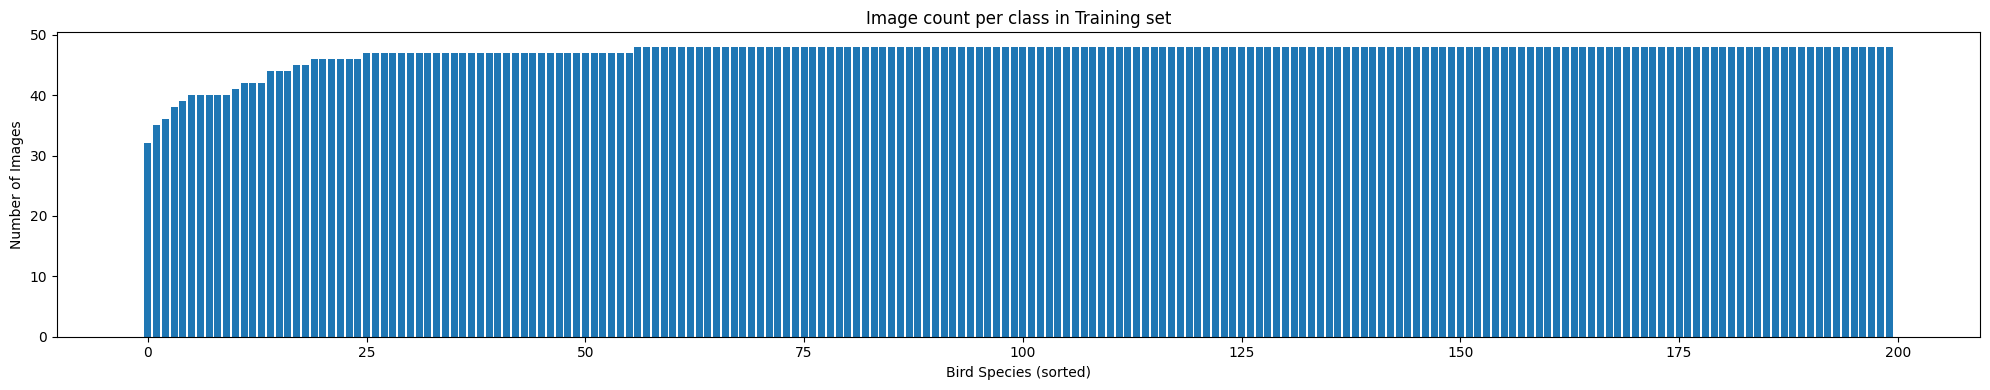

In [3]:
# Count images per class
counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes}

print(f"Min images/class : {min(counts.values())}  ({min(counts, key=counts.get)})")
print(f"Max images/class : {max(counts.values())}  ({max(counts, key=counts.get)})")
print(f"Avg images/class : {np.mean(list(counts.values())):.1f}")

# Plot distribution
plt.figure(figsize=(20, 4))
plt.bar(range(200), sorted(counts.values()))
plt.xlabel('Bird Species (sorted)')
plt.ylabel('Number of Images')
plt.title('Image count per class in Training set')
plt.tight_layout()
plt.show()

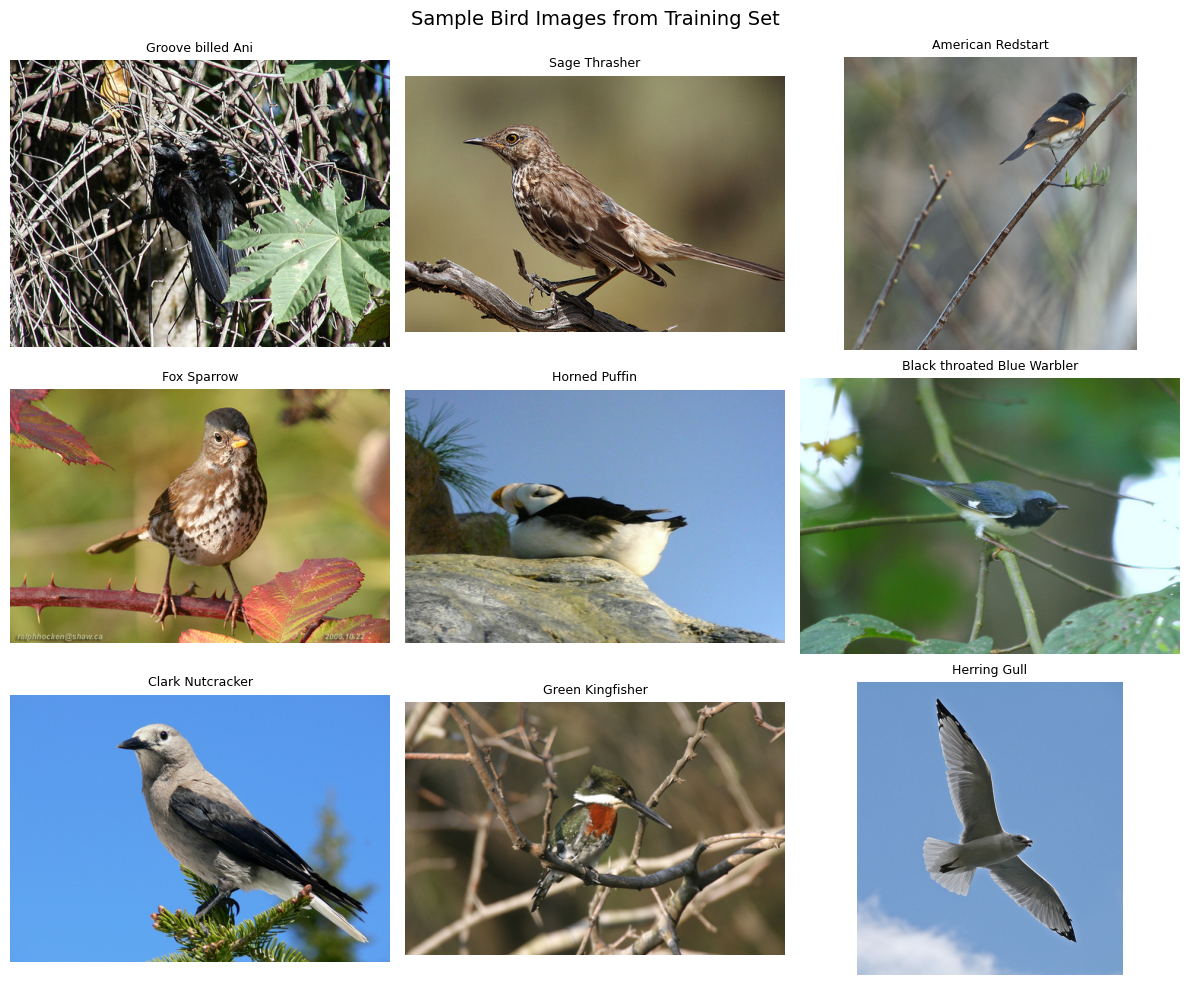

In [4]:
# Visualise sample images from 9 random classes
import random
from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
sample_classes = random.sample(train_classes, 9)

for ax, cls in zip(axes.flatten(), sample_classes):
    folder = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_file)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' '), fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Bird Images from Training Set', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
IMG_SIZE   = 224    # EfficientNet standard input
BATCH_SIZE = 32
NUM_WORKERS = 2

# Training: heavy augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test: no augmentation, just resize & normalize
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full training set, then split 80/20 for validation
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_data  = datasets.ImageFolder(TEST_DIR,  transform=val_transforms)

val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))

# For val_data, apply val_transforms (override the train augmentation)
val_data.dataset = copy.deepcopy(full_train)
val_data.dataset.transform = val_transforms

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(full_train.classes)
CLASS_NAMES = full_train.classes

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
print(f"Total classes : {NUM_CLASSES}")

Train batches : 236
Val   batches : 59
Test  batches : 75
Total classes : 200


In [6]:
def build_model(num_classes, freeze_backbone=True):
    # EfficientNet-B3: best accuracy/speed tradeoff for this dataset
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 186MB/s]


Trainable params : 889,544 / 11,585,776


In [8]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_weights = None

print("=" * 60)
print("PHASE 1: Training classifier head only")
print("=" * 60)

for epoch in range(5):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1:2d}/5  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  |  "
          f"Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc*100:.2f}%  |  "
          f"{elapsed:.0f}s")

print(f"\nBest Val Accuracy (Phase 1): {best_val_acc*100:.2f}%")

PHASE 1: Training classifier head only
Epoch  1/5  |  Train Loss: 4.6926  Train Acc: 7.50%  |  Val Loss: 3.7150  Val Acc: 23.27%  |  70s
Epoch  2/5  |  Train Loss: 3.6577  Train Acc: 23.77%  |  Val Loss: 3.1697  Val Acc: 35.87%  |  51s
Epoch  3/5  |  Train Loss: 3.3116  Train Acc: 32.18%  |  Val Loss: 2.9855  Val Acc: 39.16%  |  51s
Epoch  4/5  |  Train Loss: 3.1201  Train Acc: 37.33%  |  Val Loss: 2.8594  Val Acc: 42.77%  |  51s
Epoch  5/5  |  Train Loss: 3.0210  Train Acc: 40.52%  |  Val Loss: 2.8221  Val Acc: 44.10%  |  51s

Best Val Accuracy (Phase 1): 44.10%


In [10]:
# Unfreeze ALL layers
for param in model.parameters():
    param.requires_grad = True

# Much lower LR to avoid destroying ImageNet weights
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

print("=" * 60)
print("PHASE 2: Fine-tuning full model")
print("=" * 60)

for epoch in range(10):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        print(f"  ✅ New best: {best_val_acc*100:.2f}%")

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1:2d}/10 |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc*100:.2f}%  |  "
          f"Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc*100:.2f}%  |  "
          f"{elapsed:.0f}s")

print(f"\nBest Val Accuracy (Phase 2): {best_val_acc*100:.2f}%")

# Load best weights
model.load_state_dict(best_weights)

PHASE 2: Fine-tuning full model
  ✅ New best: 60.84%
Epoch  1/10 |  Train Loss: 2.6196  Train Acc: 50.33%  |  Val Loss: 2.2812  Val Acc: 60.84%  |  60s
  ✅ New best: 64.61%
Epoch  2/10 |  Train Loss: 2.2773  Train Acc: 61.98%  |  Val Loss: 2.1224  Val Acc: 64.61%  |  60s
  ✅ New best: 69.08%
Epoch  3/10 |  Train Loss: 2.1005  Train Acc: 67.22%  |  Val Loss: 2.0213  Val Acc: 69.08%  |  60s
  ✅ New best: 71.15%
Epoch  4/10 |  Train Loss: 1.9662  Train Acc: 71.97%  |  Val Loss: 1.9484  Val Acc: 71.15%  |  60s
  ✅ New best: 71.89%
Epoch  5/10 |  Train Loss: 1.8690  Train Acc: 75.65%  |  Val Loss: 1.9176  Val Acc: 71.89%  |  61s
  ✅ New best: 72.95%
Epoch  6/10 |  Train Loss: 1.7918  Train Acc: 78.53%  |  Val Loss: 1.8779  Val Acc: 72.95%  |  60s
Epoch  7/10 |  Train Loss: 1.7332  Train Acc: 79.82%  |  Val Loss: 1.8621  Val Acc: 72.95%  |  60s
  ✅ New best: 73.86%
Epoch  8/10 |  Train Loss: 1.6910  Train Acc: 81.60%  |  Val Loss: 1.8469  Val Acc: 73.86%  |  60s
  ✅ New best: 74.39%
Epoch  9

<All keys matched successfully>

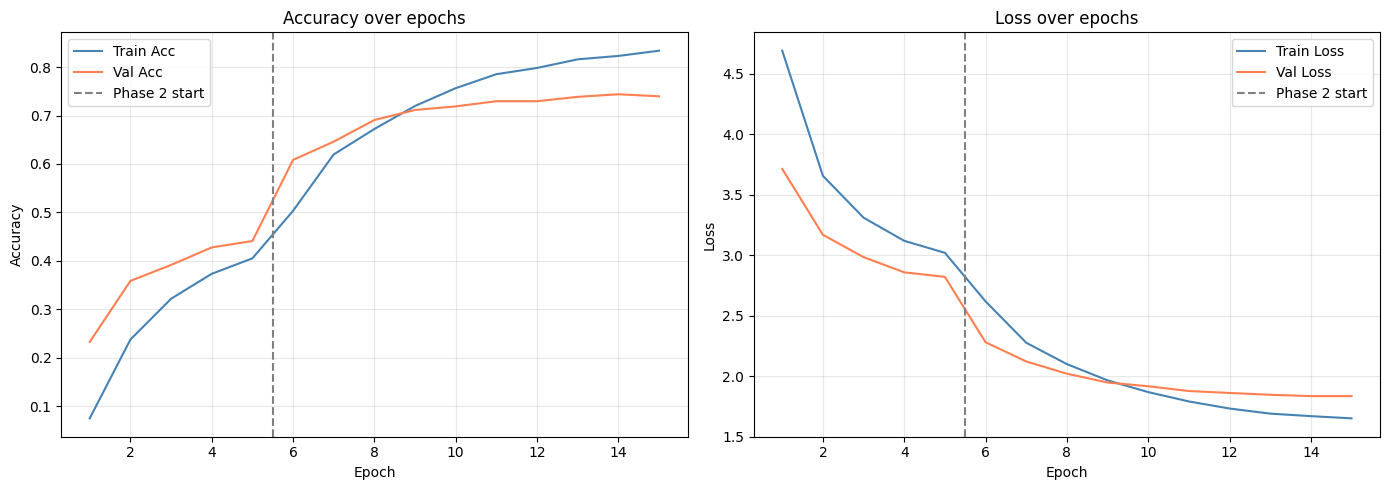

In [11]:
epochs = range(1, len(history['train_acc']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_acc'], label='Train Acc', color='steelblue')
ax1.plot(epochs, history['val_acc'],   label='Val Acc',   color='coral')
ax1.axvline(x=5.5, color='gray', linestyle='--', label='Phase 2 start')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
ax2.plot(epochs, history['val_loss'],   label='Val Loss',   color='coral')
ax2.axvline(x=5.5, color='gray', linestyle='--', label='Phase 2 start')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🎯 Final Test Accuracy: 74.60%


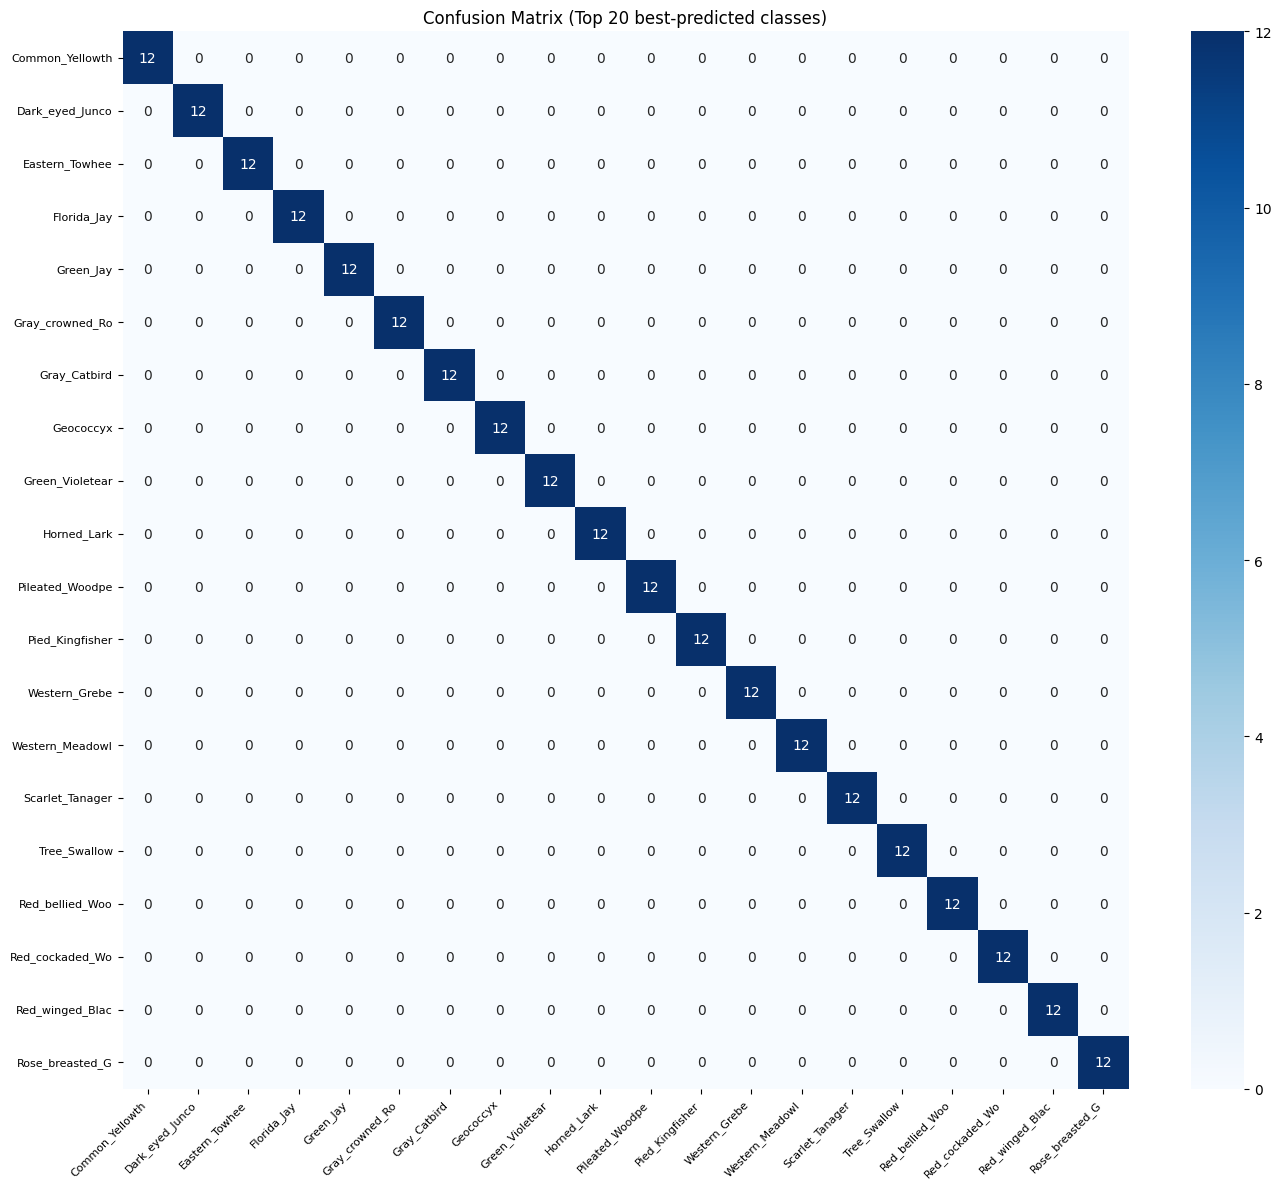

In [12]:
# Full evaluation on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"\n🎯 Final Test Accuracy: {test_acc*100:.2f}%")

# Confusion matrix (top 20 classes for readability)
cm = confusion_matrix(all_labels, all_preds)
top20_idx = np.argsort(cm.diagonal())[-20:]

plt.figure(figsize=(14, 12))
sns.heatmap(cm[np.ix_(top20_idx, top20_idx)],
            xticklabels=[CLASS_NAMES[i][:15] for i in top20_idx],
            yticklabels=[CLASS_NAMES[i][:15] for i in top20_idx],
            fmt='d', cmap='Blues', annot=True)
plt.title('Confusion Matrix (Top 20 best-predicted classes)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()